<img src="https://cdn.jsdelivr.net/gh/maxischa/datacamp_test@bf9431e/ressources/img/logo_macmia.png" alt="Banque des Territoires · France 2030 · MACMIA" width="520">

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/maxischa/datacamp_test/blob/main/bloc3_stats/cours/seance3_cours.ipynb)

# Séance 3.3 — Relier deux variables — y a-t-il un lien ?

**Cours** · durée : 2h (≈50 min de cours, ≈50 min d'exercices)

> ⚠️ **Avant de taper quoi que ce soit :** *Fichier → Enregistrer une copie dans Drive*. Sinon votre travail sera perdu en fermant l'onglet.
>
> 📱 Sur tablette, faites d'abord les réglages de [Bien démarrer](https://github.com/maxischa/datacamp_test/blob/main/ressources/setup_tablette.md).

## Objectifs

À la fin de cette séance, vous saurez :

- découper une variable quantitative en tranches avec `pd.cut`
- tester le lien entre deux variables qualitatives avec un khi-deux
- lire un tableau d'effectifs attendus pour dire *où* est la dépendance
- mesurer un lien entre deux variables quantitatives (Pearson, Spearman)
- reconnaître les trois pièges de la corrélation : extrêmes, non-linéarité, variable de confusion

## Deux questions, deux outils

1. *« Les grosses commandes sont-elles réparties de la même façon selon les
   pays ? »*
2. *« Qu'est-ce qui fait le montant d'une commande ? »*

La première croise deux variables **qualitatives** (le pays, la taille de
commande). La seconde croise deux variables **quantitatives**. Ce ne sont pas
les mêmes outils.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Affichage adapte aux petits ecrans
pd.set_option("display.max_columns", 12)
pd.set_option("display.width", 80)

# Les donnees sont lues directement depuis le web : rien a telecharger
BASE = "https://cdn.jsdelivr.net/gh/maxischa/datacamp_test@bf9431e/bloc3_stats/data/"

In [2]:
cmd = pd.read_csv(BASE + "commandes.csv")   ## une ligne = une commande

print(cmd.shape)
cmd.head(3)

(1955, 8)


,cmd_id,date,jour,ca,nart,qte,pays,client_id
0,536370,2010-12-01 08:45,mercredi,855.86,20,449,France,12583
1,536526,2010-12-01 12:58,mercredi,301.24,9,94,Royaume-Uni,14001
2,536529,2010-12-01 13:20,mercredi,161.00,9,38,Royaume-Uni,14237


## 1. Deux variables qualitatives

### D'abord, fabriquer la qualitative — `pd.cut`

`ca` est un montant, donc une variable quantitative. Pour la croiser avec le
pays, il faut en faire une variable qualitative : on la découpe en tranches.

C'est le travail de **`pd.cut`**. On lui donne une liste de **bornes** et une
liste d'**étiquettes** — une étiquette de moins que de bornes, puisque quatre
bornes délimitent trois tranches.

In [3]:
# Les bornes sont un choix de gestion, pas une verite mathematique.
# 1 000 000 = "et tout ce qui est au-dessus" : la plus grosse commande du
# fichier fait 16 775 euros, un million les couvre toutes largement.
cmd["taille"] = pd.cut(cmd["ca"], [0, 200, 500, 1000000],   ## 4 bornes, 3 tranches
                       labels=["petite", "moyenne", "grande"])

cmd["taille"].value_counts()   ## combien dans chacune ?

,count
taille,
moyenne,753
grande,685
petite,517


> ⚠️ **L'erreur classique avec `pd.cut`** : donner autant d'étiquettes que de
> bornes. Quatre bornes délimitent **trois** tranches, donc trois étiquettes.
> La cellule suivante est volontairement fausse.

In [4]:
pd.cut(cmd["ca"], [0, 200, 500, 1000000], labels=["petite", "moyenne"])

ValueError: Bin labels must be one fewer than the number of bin edges

Dernière ligne :

```
ValueError: Bin labels must be one fewer than the number of bin edges
```

Traduction : il faut exactement une étiquette de moins que de bornes. Ici
quatre bornes, donc trois étiquettes — on n'en a donné que deux. **Seule la
dernière ligne d'une erreur compte.**

### Ensuite, croiser

On garde les quatre pays les plus présents, pour un tableau lisible.

In [5]:
top4 = cmd["pays"].value_counts().head(4).index   ## les quatre plus gros
sub = cmd.query("pays in @top4")   ## @ = va chercher la liste des top 4

tableau = pd.crosstab(sub["pays"], sub["taille"])   ## lignes, puis colonnes
tableau

taille,petite,moyenne,grande
pays,,,
Allemagne,67,93,92
France,58,108,87
Irlande,29,70,157
Royaume-Uni,278,337,183


L'Irlande compte 157 grosses commandes pour 29 petites ; le Royaume-Uni,
183 grosses pour 278 petites. Les profils ont l'air différents.

**« Ont l'air » ne suffit pas.** Ces écarts sont-ils trop grands pour du
hasard ? C'est la question du **khi-deux**.

Avant de la poser, une tournure de langage, parce qu'elle revient dans tout le
bloc 4 : `chi2_contingency` ne rend pas un résultat, mais **quatre d'un coup**.
On les récupère en écrivant quatre noms à gauche du `=`, séparés par des
virgules. Python distribue les résultats dans les noms, **dans l'ordre** :

| Le nom | Ce qu'il reçoit |
|---|---|
| `khi2` | l'écart total entre le tableau observé et le tableau attendu, résumé en un nombre |
| `p` | la p-value — la seule qu'on lira ici |
| `ddl` | le nombre de cases du tableau libres une fois les totaux fixés — il dépend de la taille du tableau, pas du nombre de commandes |
| `attendus` | le tableau des effectifs **attendus** si le pays n'y était pour rien |

> ⚠️ **C'est la position qui décide, pas le nom.** `p, khi2, ddl, attendus = ...`
> ne déclenche **aucune erreur** : vous liriez « p = 140,9 » sans être prévenu.
> Recopiez l'ordre, ne l'inventez pas.

Quand un des quatre ne sert pas, l'usage est de le nommer `_` : un nom
ordinaire, dont la seule fonction est de dire « celui-là, je le jette ».

> 📖 **Statistique de test et degrés de liberté.** Toute la mécanique d'un test
> tient dans ces deux nombres. La **statistique** résume en une valeur l'écart
> entre ce qu'on observe et ce qu'on attendrait si le pays n'y était pour rien :
> plus elle est grande, plus l'écart est marqué. Les **degrés de liberté** disent
> à quelle échelle la juger — un grand tableau produit naturellement de plus gros
> écarts. Les deux ensemble donnent la p-value, et c'est elle seule qu'on lit.
> [Statistique de test](https://fr.wikipedia.org/wiki/Statistique_de_test) · [Degrés de liberté](https://fr.wikipedia.org/wiki/Degr%C3%A9_de_libert%C3%A9_%28statistiques%29)

In [6]:
# Quatre resultats, quatre noms, dans l'ordre
khi2, p, ddl, attendus = stats.chi2_contingency(tableau)

print("p-value :", p)   ## minuscule : la dependance est certaine

p-value : 6.500501643730163e-28


**p inférieure à 10⁻²⁷.** La répartition des tailles de commande
dépend bel et bien du pays. Ce n'est pas du hasard.

### Mais *où* est la dépendance ?

Le test dit qu'il y en a une. Il ne dit pas laquelle. Pour l'écrire dans une
note, il faut comparer ce qu'on observe à ce qu'on **attendrait** si le pays
n'y était pour rien.

In [7]:
att = pd.DataFrame(attendus, index=tableau.index, columns=tableau.columns)

(tableau - att).round(1)   ## observe moins attendu : OU est la dependance

taille,petite,moyenne,grande
pays,,,
Allemagne,-2.8,-5.3,8.1
France,-12.1,9.3,2.8
Irlande,-41.9,-29.8,71.8
Royaume-Uni,56.9,25.8,-82.7


Maintenant on peut écrire quelque chose :

- **Irlande : +71,8 grosses commandes** par rapport à l'attendu, et −39,2
  petites. C'est un profil de gros acheteur.
- **Royaume-Uni : −82,7 grosses**, +65,5 petites. Un profil de détail.

> 💡 **Le réflexe.** Un khi-deux significatif n'est jamais une conclusion,
> c'est un feu vert pour aller regarder le tableau des écarts. C'est là
> qu'est l'information.

## 2. Deux variables quantitatives

Deux colonnes chiffrées cette fois, et une question de gestion : **le montant
d'une commande suit-il le nombre d'unités commandées ?** Autrement dit, une
commande deux fois plus volumineuse rapporte-t-elle deux fois plus ?

**On trace d'abord.** Toujours.

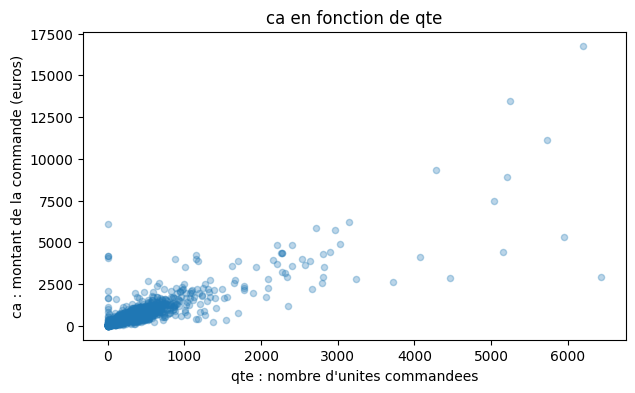

In [8]:
# On trace AVANT de calculer : un coefficient ne montre pas la forme
cmd.plot(kind="scatter", x="qte", y="ca", alpha=0.3, figsize=(7, 4))
plt.title("ca en fonction de qte")
plt.xlabel("qte : nombre d'unites commandees")
plt.ylabel("ca : montant de la commande (euros)")
plt.show()

Le lien saute aux yeux : plus d'unités commandées, plus d'euros. La
**corrélation** met
un nombre sur cette impression.

Elle vaut **1** pour une droite croissante parfaite, **−1** pour une droite
décroissante parfaite, **0** quand il n'y a aucune tendance droite.

In [9]:
cmd[["ca", "nart", "qte"]].corr().round(3)   ## toutes les paires

,ca,nart,qte
ca,1.000,0.382,0.848
nart,0.382,1.000,0.402
qte,0.848,0.402,1.000


- `ca` et `qte` : **0,85**. Très lié.
- `ca` et `nart` : **0,38**. Nettement plus faible.

Que `qte` soit plus lié au montant que `nart` n'a rien de surprenant : le
montant d'une commande se calcule à partir des **unités** vendues, pas du
nombre de produits différents. L'ordre des deux coefficients est celui qu'on
attendait.

Ce qui peut en revanche vous surprendre, c'est que 0,38 soit aussi **bas**.
Une commande portant sur 40 produits distincts coûte en général plus cher
qu'une commande qui en porte 3 : le lien existe, et on s'attendrait à le voir
plus nettement. Le reste de la section explique pourquoi ce coefficient le
montre si mal.

### Pearson et Spearman

La corrélation par défaut (**Pearson**) mesure l'alignement sur une droite.
La corrélation de **Spearman** raisonne sur les **rangs** : elle demande
seulement si l'un monte quand l'autre monte, quelle que soit la forme.

In [10]:
print("Pearson  :", round(cmd["ca"].corr(cmd["nart"]), 3))   ## une droite
print("Spearman :", round(cmd["ca"].corr(cmd["nart"], method="spearman"), 3))

Pearson  : 0.382
Spearman : 0.671


**0,38 contre 0,67.** Même couple de variables, deux réponses très
différentes. Regardez le nuage pour comprendre :

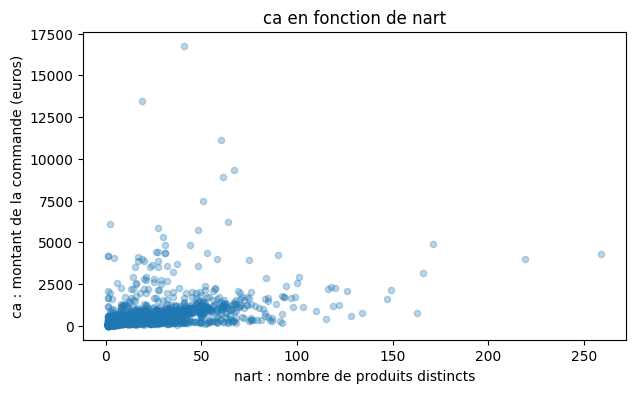

In [11]:
cmd.plot(kind="scatter", x="nart", y="ca", alpha=0.3, figsize=(7, 4))
plt.title("ca en fonction de nart")
plt.xlabel("nart : nombre de produits distincts")
plt.ylabel("ca : montant de la commande (euros)")
plt.show()

Le lien existe, mais il est **affecté par des valeurs aberrantes** : une
poignée de commandes énormes étirent l'échelle, et le nuage cesse de suivre
une droite. Pearson, qui cherche cette droite, sous-estime. Spearman, qui ne
regarde que l'ordre, voit le lien réel.

> 💡 **La règle.** Quand Pearson et Spearman divergent nettement, c'est que la
> relation n'est pas droite, ou que des valeurs extrêmes pèsent lourd. Les
> deux cas se voient sur le nuage de points, jamais dans le coefficient.

### Le poids des extrêmes

In [12]:
seuil = cmd["ca"].quantile(0.99)   ## le montant des 1 % du haut
sans = cmd.query("ca < @seuil")    ## 20 lignes sur 1 955 en moins

print("avec :", round(cmd["ca"].corr(cmd["nart"]), 3))
print("sans :", round(sans["ca"].corr(sans["nart"]), 3), "-", len(cmd) - len(sans), "lignes en moins")

avec : 0.382
sans : 0.489 - 20 lignes en moins


**0,38 → 0,49 en retirant 20 lignes sur 1 955.**

Un coefficient de corrélation cité sans le nuage de points qui va avec n'est
pas un résultat.

## 3. Ce qu'il faut vérifier avant de conclure d'une corrélation

Un coefficient est un nombre : il ne dit ni d'où viennent les variables, ni
sur quelle population il a été calculé. Deux vérifications, avant d'écrire
quoi que ce soit.

### Vérification 1 — les deux variables sont-elles mesurées indépendamment ?

`qte` et `ca` corrèlent à 0,85. Rien d'étonnant : **le montant d'une commande
se calcule à partir des quantités**. Une variable et un de ses composants
corrèlent toujours fortement, et ce coefficient n'apprend rien sur le
comportement d'achat — il ne fait que retrouver la formule de facturation.

Une corrélation n'est une information que si les deux variables sont mesurées
**indépendamment** l'une de l'autre.

### Vérification 2 — le coefficient global décrit-il une seule population ?

In [13]:
for pays in ["Belgique", "France", "Royaume-Uni", "Irlande"]:
    d = cmd.query("pays == @pays")   ## un marche a la fois
    print(pays, ":", round(d["ca"].corr(d["nart"]), 3))

Belgique : 0.903
France : 0.505
Royaume-Uni : 0.436
Irlande : 0.234


**0,90 en Belgique, 0,23 en Irlande.** Le 0,38 global n'est le chiffre de
personne : c'est la moyenne de situations qui n'ont rien à voir entre elles.

Et l'Irlande, vous savez pourquoi : **deux clients**. Ce n'est pas le pays qui
produit ce comportement d'achat, c'est le **type de client** — deux grossistes
qui commandent en volume. Le pays n'est qu'une étiquette posée par-dessus.

Le type de client est ici une **variable de confusion** : une troisième
variable, non mesurée dans le fichier, qui influence à la fois ce qu'on croit
observer et la façon dont les observations se répartissent entre les groupes.
Tant qu'elle n'est pas prise en compte, aucun des trois coefficients ne
répond à la question posée.

> ⚠️ **Le réflexe.** Avant de commenter un coefficient, demandez-vous
> **sur qui** il a été calculé, puis : **existe-t-il un Z qui expliquerait à
> la fois X et Y ?** Ici, Z est « ce client est un grossiste ».

C'est aussi, incidemment, la raison pour laquelle **une corrélation n'est pas
une causalité** : la formule qui produit le coefficient ne contient aucune
information sur ce qui cause quoi. Elle ne sait pas distinguer « X agit sur
Y » de « Z agit sur les deux ». Vous verrez en séance 3.4 comment un modèle
de régression permet de mettre plusieurs variables dans le calcul en même
temps — c'est la première réponse technique à ce problème.

## 4. La corrélation ne voit que les relations linéaires

Vous en avez déjà vu un cas atténué en partie 2 : `ca` et `nart` donnent 0,38
en Pearson et 0,67 en Spearman, parce que **le nuage ne se range pas le long
d'une droite**. Pearson cherche cette droite là où la relation n'en suit pas,
et il sous-estime.

Poussons le raisonnement jusqu'au bout. Voici deux colonnes où `y` est
**entièrement déterminé** par `x` — une parabole exacte, sans la moindre part
de hasard.

In [14]:
x = pd.Series(range(-50, 51))
y = x ** 2   ## lien parfait, mais en forme de U

print("Pearson  :", round(x.corr(y), 3))   ## 0,000 : la droite n'y est pas
print("Spearman :", round(x.corr(y, method="spearman"), 3))

Pearson  : 0.0
Spearman : 0.0


**0,000 pour les deux coefficients.** Un lien parfait, et deux mesures nulles.

La corrélation ne mesure pas « y a-t-il un lien ». Elle mesure « quand `x`
augmente, est-ce que `y` augmente **régulièrement** ? ». Ici la courbe descend
puis remonte : sur la moitié gauche `y` baisse quand `x` monte, sur la moitié
droite il monte, et les deux moitiés s'annulent exactement.

Notez que **Spearman ne sauve pas la mise**. Il corrige les relations courbes
mais **croissantes** — c'était le cas de `ca`/`nart`. Il ne peut rien faire
d'une relation qui change de sens en cours de route.

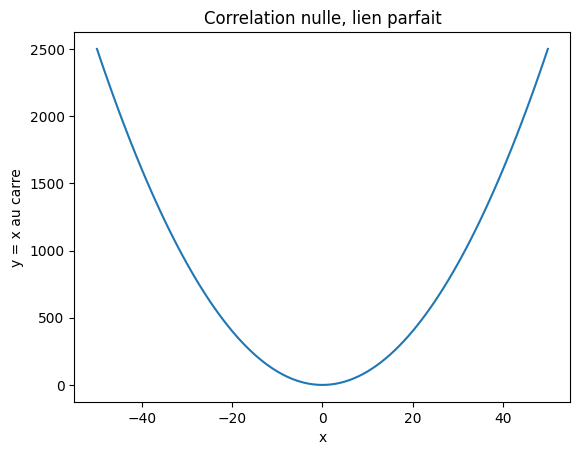

In [15]:
plt.plot(x, y)
plt.title("Correlation nulle, lien parfait")
plt.xlabel("x")
plt.ylabel("y = x au carre")
plt.show()

Trente secondes de graphique auraient évité la conclusion « ces deux variables
n'ont rien à voir ».

Ce cas n'a rien d'un exercice d'école. Les relations qui changent de sens sont
partout en gestion : une remise fait monter les ventes puis les fait baisser
quand elle inquiète sur la qualité ; l'effet d'une pression publicitaire
plafonne puis se retourne. Sur toutes ces relations, un coefficient de
corrélation proche de zéro ne veut **pas** dire « aucun lien ».

> ⚠️ **Tracez toujours avant de conclure.** Un coefficient résume une forme ;
> il ne la montre pas. Et il ne prévient jamais quand il ne convient pas.

---

## Ce que vous savez faire maintenant

| Vous voulez... | La commande |
|---|---|
| découper une variable continue | `pd.cut(df["ca"], [0, 200, 500, 1000000], labels=[...])` |
| croiser deux qualitatives | `pd.crosstab(df["pays"], df["taille"])` |
| nommer d'un coup les quatre résultats | `khi2, p, ddl, attendus = ...` |
| jeter un résultat inutile | `khi2, p, _, attendus = ...` |
| tester leur lien | `stats.chi2_contingency(tableau)` |
| les effectifs attendus si indépendance | `stats.chi2_contingency(tableau)[3]` |
| toutes les corrélations d'un coup | `df[["ca", "nart", "qte"]].corr()` |
| une corrélation entre deux colonnes | `df["ca"].corr(df["qte"])` |
| la version robuste (rangs) | `df["ca"].corr(df["qte"], method="spearman")` |
| voir le lien | `df.plot(kind="scatter", x="qte", y="ca")` |

## Choisir son outil

| Variable 1 | Variable 2 | Outil |
|---|---|---|
| qualitative | qualitative | tableau croisé + khi-deux |
| quantitative | quantitative | nuage de points + corrélation |
| qualitative | quantitative | comparaison de moyennes (séance 3.2) |

## Les trois pièges

1. **Les extrêmes.** Retirer 1 % des commandes fait passer la corrélation
   `ca`/`nart` de 0,38 à 0,49. Vingt lignes sur 1 955.
2. **La non-linéarité.** Une corrélation nulle ne veut pas dire « aucun
   lien », mais « aucun lien **régulièrement croissant ou décroissant** ». Sur
   `y = x²`, Pearson **et** Spearman valent 0. **Tracez toujours.**
3. **Les variables de confusion.** Le 0,38 global vaut 0,90 en Belgique et
   0,23 en Irlande : ce n'est pas le pays qui agit, c'est le type de client.
   Et `qte`/`ca` corrèlent à 0,85 simplement parce que `qte` sert à calculer
   `ca`. Demandez toujours **sur qui** le coefficient a été calculé, et **quel
   Z** pourrait expliquer X et Y à la fois.